# Motion tuning

This notebook generates the plots for Supp Figures 9 & 10. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [17]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import torch
import pandas as pd
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import wilcoxon

from brainbox import tuning
from retina import train, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [19]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

In [20]:
torch.manual_seed(0)
grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)

## Supp Fig 9 Object motion sensitivity to jittered motion

In [21]:
#Get the tuning sensitivity
display_tuning = False
torch.manual_seed(0)
grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)
query = tuning.TuningQuery(f"{root}/data/tuning/rec_ablate_False")
tuning_df = query.validate(response_threshold=0.05, fit_threshold=0.0)

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Automatically adjust the width
pd.set_option('display.max_colwidth', None)  # Display full column content

if display_tuning:
    tuning_df

In [22]:
#Get the receptive field properties
display_rfs = False
torch.manual_seed(0)
rf_query = analysis.RFQuery(root, model)
if display_rfs:
    rf_query.params_df

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 219
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12


In [23]:
def plot_grating_and_raster(title, grating, raster_x, raster_y, ax_grating, ax_raster, probe_ms=3000):
    ax_grating.imshow(grating, cmap="Greys", vmin=-1, vmax=1)
    ax_raster.scatter(raster_x, raster_y+1, s=1, c="black")
    ax_grating.set_title(title, fontsize=14, pad=8)
    ax_grating.set_xticks([])
    ax_grating.set_yticks([])
    ax_grating.spines["top"].set_linewidth(2)
    ax_grating.spines["bottom"].set_linewidth(2)
    ax_grating.spines["left"].set_linewidth(2)
    ax_grating.spines["right"].set_linewidth(2)
    
    ax_raster.spines["top"].set_visible(False)
    ax_raster.spines["right"].set_visible(False)
    ax_raster.spines["bottom"].set_linewidth(2)
    ax_raster.spines["left"].set_linewidth(2)
    ax_raster.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.set_yticks([1, 8])
    ax_raster.set_xticks([0, 240, 480, 720, 960, 1200, 1440, 1680, 1920, 2160, 2400])
    ax_raster.set_xticklabels([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    ax_raster.set_xlabel("Time (s)", fontsize=14, labelpad=8)
    ax_raster.set_ylabel("Trial", fontsize=14, labelpad=2)

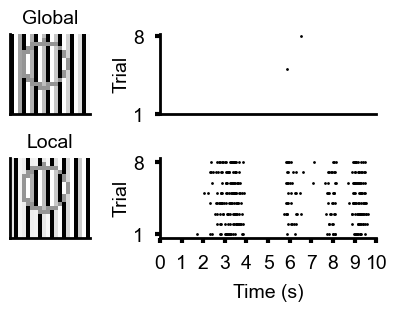

In [24]:
#New analysis by Nicol
#Run differential motion for select valid neurons and plot results
torch.manual_seed(0)#80
ratio = []
activity = []
cell_type = []
spatial_freq = 0.33
temporal_freq = 3
radius = 3
luminance = 1.5
probe_ms = 10000
xy0min = -1
xy0max = 20
select_cells = range(400)
#select_cells = [40, 72, 99, 108, 192, 214, 246, 250, 283, 323, 386]
select_cells = [214]

for n in select_cells:
    torch.manual_seed(0)#80
    
    rfvec = rf_query.params_df.og_index==n
    tunvec = tuning_df.index==n
    if any(rfvec):# and any(tunvec):

        theta = tuning_df.loc[tunvec, 'theta'].iloc[0]
        sf    = tuning_df.loc[tunvec, 'sf'].iloc[0]
        tf    = tuning_df.loc[tunvec, 'tf'].iloc[0]
        x0    = rf_query.params_df.loc[rfvec, 'x0'].iloc[0]
        y0    = rf_query.params_df.loc[rfvec, 'y0'].iloc[0]
        rfsize = np.sqrt(rf_query.params_df.loc[rfvec, 'size'].iloc[0])
        differential_motion = analysis.JitteredDifferentialMotion(model, unit_idx=n, theta=0, spatial_freq=spatial_freq,
                                                          temporal_freq=temporal_freq, y0=y0, x0=x0, r=5,
                                                          lum=luminance, probe_ms=probe_ms, moving_background=True,
                                                          ablate_recurrence=False)

        fig = plt.figure(constrained_layout=True, figsize=(4, 3))
        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
        ax1 = fig.add_subplot(spec[0, :2])
        ax2 = fig.add_subplot(spec[0, 2:]) 
        ax3 = fig.add_subplot(spec[1, :2])
        ax4 = fig.add_subplot(spec[1, 2:])

        plot_grating_and_raster("Global", differential_motion.masked_grating_global[1000],
                                *differential_motion.global_raster, ax1, ax2, probe_ms)
        ax2.set_xticks([])
        ax2.set_xlabel("")
        plot_grating_and_raster("Local", differential_motion.masked_grating_local[1000],
                                *differential_motion.local_raster, ax3, ax4, probe_ms)
        #ax2.set_title(f"Unit numI am intermitantly in severe pain at the moment and need to go to an out-of-hours doctor at 5pm. I will get back to it after that if I can manage it.ber {n}",fontsize=14)
        
        plt.savefig(f"{root}/figures/fig4/motion_selectivity_raster.svg", format="svg",
                    transparent=False, bbox_inches="tight")
        
        #print([differential_motion.global_raster[0].size, differential_motion.local_raster[0].size])
        if differential_motion.local_raster[0].size>0:
            ratio.append(differential_motion.global_raster[0].size/differential_motion.local_raster[0].size)
        else:
            if differential_motion.global_raster[0].size>0:
                ratio.append(10)
            else:
                ratio.append(100)
        activity.append(differential_motion.global_raster[0].size + differential_motion.local_raster[0].size)
        cell_type.append(rf_query.params_df.loc[rfvec, 'type'].iloc[0])
        plt.savefig(f"{root}/figures/supp/jittered_object_motion.svg", format="svg", transparent=False, bbox_inches="tight")

In [25]:
#Get object motion sensitivity rate for firing rate between global and local
#do this for both standard model and ablated model, and do this multiple times
#then get statistics of this measure

#This can take a day or more to run, better to just load pre-run version

loadfile = True#True
    
if not loadfile:

    spatial_freq = 0.33
    temporal_freq = 3
    radius = 3
    luminance = 1.5
    xy0min = -1
    xy0max = 20

    plot_results = False
    num = 10
    ratio = [[] for _ in range(num)]
    osmi = [[] for _ in range(num)]
    activity = [[] for _ in range(num)]
    cell_type= [[] for _ in range(num)]
    global_spikes = [[] for _ in range(num)]
    local_spikes = [[] for _ in range(num)]
    ratio_ablate = [[] for _ in range(num)]
    osmi_ablate = [[] for _ in range(num)]
    activity_ablate = [[] for _ in range(num)]
    cell_type_ablate= [[] for _ in range(num)]
    global_spikes_ablate = [[] for _ in range(num)]
    local_spikes_ablate = [[] for _ in range(num)]


    # run analysis a number of times
    for nr in range(num):
        print("repeat number")
        print(nr)

        torch.manual_seed(0+4*nr)

        #count through every unit
        for n in range(400):

            #check has a receptive field and grating responsivity
            rfvec = rf_query.params_df.og_index==n
            if any(rfvec):
                x0 = rf_query.params_df.loc[rfvec, 'x0'].iloc[0]
                y0 = rf_query.params_df.loc[rfvec, 'y0'].iloc[0]
                if xy0min < x0 < xy0max and xy0min < y0 < xy0max: # and any(tunvec):

                    #get parameters
                    torch.manual_seed(0+4*nr)
                    differential_motion = analysis.JitteredDifferentialMotion(model, unit_idx=n, theta=0, 
                                                                      spatial_freq=spatial_freq,
                                                                      temporal_freq=temporal_freq,
                                                                      y0=y0, x0=x0, r=radius,
                                                                      lum=luminance, moving_background=True,
                                                                      ablate_recurrence=False)
                    torch.manual_seed(0+4*nr)
                    differential_motion_ablate = analysis.JitteredDifferentialMotion(model, unit_idx=n, theta=0, 
                                                                      spatial_freq=spatial_freq,
                                                                      temporal_freq=temporal_freq,
                                                                      y0=y0, x0=x0, r=radius,
                                                                      lum=luminance, moving_background=True,
                                                                      ablate_recurrence=True)

                    local_spikes_temp = differential_motion.local_raster[0].size
                    global_spikes_temp = differential_motion.global_raster[0].size
                    local_spikes_ablate_temp = differential_motion_ablate.local_raster[0].size
                    global_spikes_ablate_temp = differential_motion_ablate.global_raster[0].size
                    local_spikes[nr].append(local_spikes_temp)
                    global_spikes[nr].append(global_spikes_temp)
                    local_spikes_ablate[nr].append(local_spikes_ablate_temp)
                    global_spikes_ablate[nr].append(global_spikes_ablate_temp)

                    #standard ratio
                    if local_spikes_temp>0:
                        ratio_temp = global_spikes_temp/local_spikes_temp
                    else:
                        if global_spikes_temp>0:
                            ratio_temp = np.nan
                        else:
                            ratio_temp = 1
                    ratio[nr].append(ratio_temp)

                    #ablated ratio
                    if local_spikes_ablate_temp>0:
                        ratio_ablate_temp = global_spikes_ablate_temp/local_spikes_ablate_temp
                    else:
                        if global_spikes_ablate_temp>0:
                            ratio_ablate_temp = np.nan
                        else:
                            ratio_ablate_temp = 1
                    ratio_ablate[nr].append(ratio_ablate_temp)

                    #standard osmi
                    if (local_spikes_temp +
                        global_spikes_temp)>0:
                        osmi_temp = (local_spikes_temp -
                                     global_spikes_temp) / \
                                    (local_spikes_temp +
                                     global_spikes_temp)
                    else:
                        osmi_temp = 0                            
                    osmi[nr].append(osmi_temp)          

                    #ablated osmi
                    if (local_spikes_ablate_temp +
                        global_spikes_ablate_temp)>0:
                        osmi_ablate_temp = (local_spikes_ablate_temp -
                                     global_spikes_ablate_temp) / \
                                    (local_spikes_ablate_temp +
                                     global_spikes_ablate_temp)
                    else:
                        osmi_ablate_temp = 0                            
                    osmi_ablate[nr].append(osmi_ablate_temp)         

                    activity[nr].append(global_spikes_temp+local_spikes_temp)
                    cell_type[nr].append(rf_query.params_df.loc[rfvec, 'type'].iloc[0])

                    if plot_results:
                        fig = plt.figure(constrained_layout=True, figsize=(4, 3))
                        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
                        ax1 = fig.add_subplot(spec[0, :2])
                        ax2 = fig.add_subplot(spec[0, 2:]) 
                        ax3 = fig.add_subplot(spec[1, :2])
                        ax4 = fig.add_subplot(spec[1, 2:])

                        plot_grating_and_raster("Global", differential_motion.masked_grating_global[420-40],
                                                *differential_motion.global_raster, ax1, ax2)
                        ax2.set_xticks([])
                        ax2.set_xlabel("")
                        ratio_temp_3sf = f"{ratio_temp:.3g}"
                        osmi_temp_3sf = f"{osmi_temp:.3g}"
                        ax2.set_title(f"{global_spikes_temp}, {ratio_temp_3sf}, {osmi_temp_3sf}", fontsize=16)

                        plot_grating_and_raster("Local", differential_motion.masked_grating_local[420-40],
                                                *differential_motion.local_raster, ax3, ax4)
                        ax4.set_title(str(differential_motion.local_raster[0].size),fontsize=16)

                        fig = plt.figure(constrained_layout=True, figsize=(4, 3))
                        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
                        ax1 = fig.add_subplot(spec[0, :2])
                        ax2 = fig.add_subplot(spec[0, 2:]) 
                        ax3 = fig.add_subplot(spec[1, :2])
                        ax4 = fig.add_subplot(spec[1, 2:])

                        plot_grating_and_raster("Global", differential_motion_ablate.masked_grating_global[420-40],
                                                *differential_motion_ablate.global_raster, ax1, ax2)
                        ax2.set_xticks([])
                        ax2.set_xlabel("")
                        ratio_ablate_temp_3sf = f"{ratio_ablate_temp:.3g}"
                        osmi_ablate_temp_3sf = f"{osmi_ablate_temp:.3g}"
                        ax2.set_title(f"{global_spikes_ablate_temp}, {ratio_ablate_temp_3sf}, {osmi_ablate_temp_3sf}", fontsize=16)

                        plot_grating_and_raster("Local", differential_motion_ablate.masked_grating_local[420-40],
                                                *differential_motion_ablate.local_raster, ax3, ax4)
                        ax4.set_title(str(differential_motion_ablate.local_raster[0].size),fontsize=16)



In [26]:
# Load old file if needed

tuning_folder = os.path.join(root, "data", "tuning")

loadfile = True#
verbose = False

if loadfile:
    
    # Define a SafeUnpickler that replaces missing functions with harmless dummy functions
    class SafeUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            missing_functions = {
                'plot_XS_units',
                'plot_orientation_tuning',
                'plot_grating_and_raster',
                'get_stats',
                'flatten_stats',
                'interleave',
                'mean_and_sem',
            }
            if name in missing_functions:
                if verbose:
                    print(f"Replacing missing function '{name}' with a dummy.")
                return lambda *args, **kwargs: None
            return super().find_class(module, name)

    # Construct full path to the file
    filename = os.path.join(tuning_folder, "Fig4variables_26Jul2025_tight3_ring1_240Hz_all_10repeats_200seconds_good_short.pkl")

    # Safely load
    with open(filename, "rb") as f:
        loaded_vars = SafeUnpickler(f).load()

    # Optional: update your global scope
    globals().update(loaded_vars)

In [27]:
# Get final numbers and stats

# Stack across repeats
osmia_all = np.array(osmi)                # Shape: [repeats, units]
activitya_all = np.array(activity)
osmia_ablate_all = np.array(osmi_ablate)

# Average activity across repeats to determine "active" units
mean_activity = np.mean(activitya_all, axis=0)
active_mask = mean_activity > 10

# Filter only active units in each repeat
osmia_active = osmia_all[:, active_mask]
osmia_ablate_active = osmia_ablate_all[:, active_mask]

# Compute mean and SEM across repeats for each unit group
def mean_and_sem(data):
    mean = np.mean(data, axis=0)  # mean per unit across repeats
    sem = np.std(data, axis=0, ddof=1) / np.sqrt(data.shape[0])
    return np.mean(mean), np.mean(sem)  # average across units

# Get stats for 'all' (active units only)
osmi_mean, osmi_sem = mean_and_sem(osmia_active)
osmi_ablate_mean, osmi_ablate_sem = mean_and_sem(osmia_ablate_active)

# Print results
print("\nMean ± SEM across repeats (active units only):")
print(f"OMSI Intact:   {osmi_mean:.3f} ± {osmi_sem:.3f}")
print(f"OMSI Ablated:  {osmi_ablate_mean:.3f} ± {osmi_ablate_sem:.3f}")

# Prepare data for Wilcoxon signed-rank test
# Average across units per repeat
osmi_intact_per_repeat = np.mean(osmia_active, axis=1)
osmi_ablated_per_repeat = np.mean(osmia_ablate_active, axis=1)

# Wilcoxon signed-rank test (non-parametric paired test)
w_stat, p_val = wilcoxon(osmi_intact_per_repeat, osmi_ablated_per_repeat)
print(f"\nWilcoxon signed-rank test: W = {w_stat:.3f}, p = {p_val:.4f}")



Mean ± SEM across repeats (active units only):
OMSI Intact:   0.112 ± 0.026
OMSI Ablated:  0.104 ± 0.027

Wilcoxon signed-rank test: W = 1.000, p = 0.0039


In [28]:
# Save results if needed
save_results = False
save_mode = 'short'  # 'full' or 'short'

# For short version, list of variables to keep
short_vars = ['osmi', 'osmi_ablate', 'activity']  

# Define save folder
root = os.path.expanduser("~/PycharmProjects/RetinalModel")
save_folder = os.path.join(root, "data", "tuning")

if save_results:
    
    # Make a copy of globals().items() to avoid RuntimeError
    variables = []
    for name, val in list(globals().items()):
        if not name.startswith("_"):
            try:
                size = sys.getsizeof(val)
                variables.append((name, type(val).__name__, size))
            except:
                pass  # Safely skip any problematic objects

    # Sort variables by size descending
    variables.sort(key=lambda x: x[2], reverse=True)

    to_save = {}
    # Make a copy of globals to avoid RuntimeError
    for k, v in list(globals().items()):
        if k.startswith("_") or k == "f":
            continue
        try:
            pickle.dumps(v)  # Test if object is pickleable
            to_save[k] = v
        except (pickle.PicklingError, AttributeError, TypeError):
            pass  # Skip unpickleable objects

    base_file = os.path.join(save_folder, "Fig4variables_26Jul2025_tight3_ring1_240Hz_all_10repeats_200seconds_good.pkl")

    if save_mode == 'full':
        with open(base_file, "wb") as f:
            pickle.dump(to_save, f)
        print(f"Full pickle saved as: {base_file}")
    elif save_mode == 'short':
        short_file = base_file.replace(".pkl", "_short.pkl")
        to_save_short = {k: v for k, v in to_save.items() if k in short_vars}
        with open(short_file, "wb") as f:
            pickle.dump(to_save_short, f)
        print(f"Short pickle saved as: {short_file}")
    else:
        print("Invalid save_mode. Choose 'full' or 'short'.")

## Supp Fig 10 Population anticipation responses

In [32]:
#Function to smooth population response

# Set global plot styles
plt.rcParams.update({ 
    'font.size': 24,
    'lines.linewidth': 2.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0
})

def gaussian_smooth_to_even_grid(x, y, sigma=2, num_points=500, x_min=0, x_max=19):
    """
    Smooth y = f(x) using a Gaussian kernel, outputting smoothed y on evenly spaced x.

    Parameters:
        x (np.ndarray): 1D array of original x values (uneven spacing allowed)
        y (np.ndarray): 1D array of y values
        sigma (float): Standard deviation of the Gaussian kernel (in x units)
        num_points (int): Number of points in the evenly spaced output

    Returns:
        x_new (np.ndarray): Evenly spaced x values over the original x range
        y_smooth (np.ndarray): Smoothed y values at x_new
    """
    # Convert inputs to numpy arrays
    x = np.asarray(x)
    y = np.asarray(y)
    
    # Dynamically calculate min and max of x if not provided
    if x_min is None:
        x_min = np.min(x)
    if x_max is None:
        x_max = np.max(x)

   # Create the new evenly spaced x values (the grid over which we want to smooth)
    x_new = np.linspace(x_min, x_max, num_points)
    y_smooth = np.zeros_like(x_new)

    # Define the Gaussian kernel function
    def gaussian_kernel(xi, x_all, sigma):
        """Gaussian kernel function."""
        return np.exp(-0.5 * ((x_all - xi) / sigma) ** 2)

    #print(x)
    # For each new x point, we apply the Gaussian kernel to the neighboring points
    for i, xi in enumerate(x_new):
        # Calculate the Gaussian kernel weights for all original x points based on the current xi
        weights = gaussian_kernel(xi, x, sigma)

        # Normalize the weights so they sum to 1
        #weights = np.sum(weights)

        # Compute the weighted sum of y values for the current xi
        y_smooth[i] = np.sum(weights * y)


    return x_new, y_smooth

0 1
1 2
2 3
3 4
4 5
5 6
6 7
7 8
Speed: 0.125
Lead of peak: 1.8236472945891773


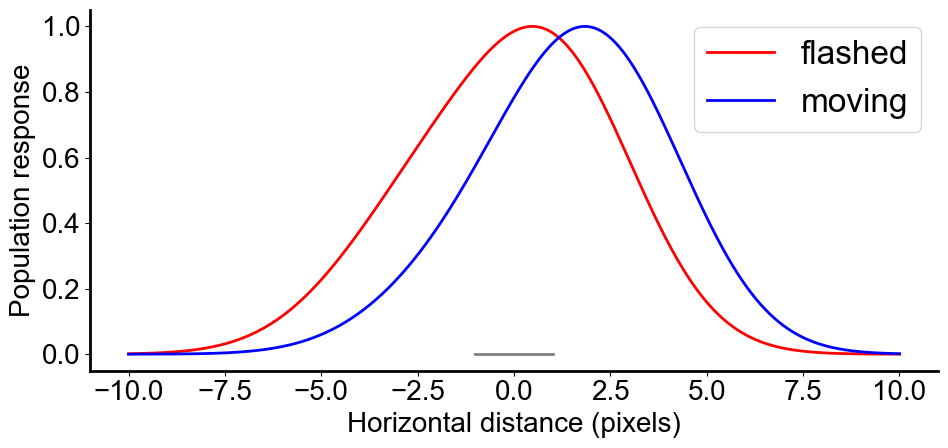

8 9
9 10
10 12
11 14
12 16
13 18
14 20


In [33]:
#This gets population responses for bars of different speeds, plots a select example,
#and then plots peak position against speed
bar_speeds = []
max_positions = []
bar_width = 3
bar_x0s = np.array([11,12,13,14], dtype=int)
directions = ['right','right','right','right','right','right','right','right','right','right','right','right','right','right','right']
bar_speeds = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20], dtype=int)
response_window = 3
response_window_flash = 1
start_early = 1
max_positions = np.zeros((bar_x0s.size, bar_speeds.size))
rel_max_positions = np.zeros((bar_speeds.size))
rel_x0 = []
rel_flash_response = []
rel_move_response = []
plot_per_position = False
plot_relative_response = False
plot_select_response = 8
add_title = False
ablate_recurrence=False
sigma = 2
fontsize = 20

direction = 'left'
for j, speedi in enumerate(bar_speeds):
    print(j, speedi)
    rel_x0 = []
    rel_flash_response = []
    rel_move_response = []
    for i, bar_x0 in enumerate(bar_x0s):
        
        direction = directions[i]
        
        torch.manual_seed(0)
        ant = analysis.anticipation.AnticipationAnalysis(model, bar_width=bar_width, bar_x0=bar_x0, luminance=0,
                                                         ablate_recurrence=ablate_recurrence, bar_speed=speedi,
                                                         smooth=True)
        x0list = []
        y0list = []
        flash_response = []
        move_response = []

        for n in range(400):
            rfvec = rf_query.params_df.og_index==n
            tunvec = tuning_df.index==n
            if any(rfvec) and (rf_query.params_df[rfvec].type.item()==1):

                x0 = rf_query.params_df[rfvec].x0.item()
                y0 = rf_query.params_df[rfvec].y0.item()
                x0list.append(x0)
                y0list.append(y0)

                if direction == 'left':
                    flash_response.append(ant.mean_left_flash_bar_firing[n,:].numpy())
                    move_response.append(ant.mean_left_moving_bar_firing[n,:].numpy())
                elif direction == 'right':                
                    flash_response.append(ant.mean_flash_bar_firing[n,:].numpy())
                    move_response.append(ant.mean_right_moving_bar_firing[n,:].numpy())
                    
        x0a = np.array(x0list)
        y0a = np.array(y0list)
        flash_responsea = np.array(flash_response)
        move_responsea = np.array(move_response)

        r_window = min(response_window,speedi)
        r_window_flash = min(response_window_flash,speedi)
        x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(x0a,
                                                                   np.mean(
                                                                       flash_responsea[:,
                                                                                       100:(100+r_window_flash)],
                                                                       axis=1),sigma=sigma)
        x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(x0a,
                                                                 np.mean(
                                                                     move_responsea[:,
                                                                                    (100-start_early):(100-start_early+r_window)],
                                                                     axis=1), sigma=sigma)
        
        
        if direction == 'left':
            rel_x0.append(-1 * (x0a - (19-(bar_x0+np.floor(bar_width/2)))))#relative to midpoint of bar
        elif direction == 'right':
            rel_x0.append(x0a - (bar_x0 + np.floor(bar_width/2)))#relative to midpoint of bar
        rel_flash_response.append(np.mean(flash_responsea[:, 100:(100+r_window_flash)],axis=1))
        rel_move_response.append(np.mean(move_responsea[:, (100-start_early):(100-start_early+r_window)],axis=1))
        
        max_position = x_new_move[np.argmax(y_smooth_move)] 
        max_peak = np.max(y_smooth_move)
        if direction == 'left':
            max_positions[i,j] = (19 - (bar_x0 + bar_width - 1)) - max_position#relative to leading edge of bar
        elif direction == 'right':
            max_positions[i,j] = max_position - (bar_x0 + bar_width - 1)#relative to leading edge of bar
        
        if plot_per_position:
            plt.figure(figsize=(10, 5))  # Create a new figure for each iteration

            # Plot flash response (smoothed)
            plt.plot(x_new_flash, y_smooth_flash, label='flashed', linewidth=2, color='red')

            # Plot move response (smoothed)
            plt.plot(x_new_move, y_smooth_move, label='moving', linewidth=2, color='blue')
            max_position = x_new_move[np.argmax(y_smooth_move)] 
            max_peak = np.max(y_smooth_move)
            if direction == 'left':
                plt.plot([19-bar_x0,19-bar_x0-1,19-bar_x0-2],[0,0,0],linewidth=2,color='gray')
            elif direction == 'right':
                plt.plot([bar_x0,bar_x0+1,bar_x0+2],[0,0,0],linewidth=2,color='gray')

            # Set title and labels
            plt.title(f"Speed {1/speedi} pixels/frame, bar x0 {bar_x0}",fontsize=fontsize)
            plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
            plt.ylabel('Response',fontsize=fontsize)
            plt.tick_params(axis='both', labelsize=fontsize) 

            # Show the plot with both responses on the same axes
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)

    rel_x0 = np.array(rel_x0)
    rel_flash_response = np.array(rel_flash_response)
    rel_move_response = np.array(rel_move_response)
        
    x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(rel_x0,rel_flash_response, x_min=-10, x_max=10,
                                                               sigma=sigma)
    x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(rel_x0,rel_move_response, x_min=-10, x_max=10,
                                                             sigma=sigma)
    rel_max_position = x_new_move[np.argmax(y_smooth_move)] 
    rel_max_peak = np.max(y_smooth_move)
    if direction == 'left':
        rel_max_positions[j] = -1 - rel_max_position
    elif direction == 'right':
        rel_max_positions[j] = rel_max_position -1
        
    if plot_relative_response or (plot_select_response==speedi):
        plt.figure(figsize=(10, 5))  # Create a new figure for each iteration

        # Plot flash response (smoothed)
        plt.plot(x_new_flash, y_smooth_flash/y_smooth_flash.max(), label='flashed', linewidth=2, color='red')

        # Plot move response (smoothed)
        plt.plot(x_new_move, y_smooth_move/y_smooth_move.max(), label='moving', linewidth=2, color='blue')
        plt.plot([-1,0,1],[0,0,0],linewidth=2,color='gray')

        # Set title and labels
        if add_title:
            ax = plt.title(f"Relative, Speed {1/speedi} pixels/frame, Rel. Posit. {rel_max_position}",fontsize=fontsize)
        else:
            print(f"Speed: {1/speedi}")
            print(f"Lead of peak: {rel_max_position}")
        plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
        plt.ylabel('Population response',fontsize=fontsize)
        plt.tick_params(axis='both', labelsize=fontsize)
        plt.grid(False)  # Remove grid
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.legend(fontsize=fontsize) 
        
        # Show the plot with both responses on the same axes
        plt.legend()
        plt.grid(False)
        plt.tight_layout()
        plt.show()



In [34]:
#This gets population responses for bars of different speeds,
#and then plots peak position against speed, with and without ablated recurrence
bar_speeds_ablate = []
max_positions_ablate = []
bar_width = 3
bar_x0s = np.array([11,12,13,14], dtype=int)
directions = ['right','right','right','right','right','right','right','right','right','right','right','right','right','right','right']
bar_speeds = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20], dtype=int)
response_window = 3
response_window_flash = 1
start_early = 1
max_positions_ablate = np.zeros((bar_x0s.size, bar_speeds.size))
rel_max_positions_ablate = np.zeros((bar_speeds.size))
rel_x0_ablate = []
rel_flash_response_ablate = []
rel_move_response_ablate = []
plot_per_position = False
plot_relative_response = False
plot_select_response = -1
add_title = False
ablate_recurrence=True
sigma = 2
fontsize = 20

direction = 'left'
for j, speedi in enumerate(bar_speeds):
    rel_x0_ablate = []
    rel_flash_response_ablate = []
    rel_move_response_ablate = []
    for i, bar_x0 in enumerate(bar_x0s):
        
        direction = directions[i]
        torch.manual_seed(0)
        torch.manual_seed(0)
        ant = analysis.anticipation.AnticipationAnalysis(model, bar_width=bar_width, bar_x0=bar_x0, luminance=0,
                                                         ablate_recurrence=ablate_recurrence, bar_speed=speedi,
                                                         smooth=True)
        x0list = []
        y0list = []
        flash_response = []
        move_response = []

        for n in range(400):
            rfvec = rf_query.params_df.og_index==n
            tunvec = tuning_df.index==n
            if any(rfvec) and (rf_query.params_df[rfvec].type.item()==1):

                x0 = rf_query.params_df[rfvec].x0.item()
                y0 = rf_query.params_df[rfvec].y0.item()
                x0list.append(x0)
                y0list.append(y0)

                if direction == 'left':
                    flash_response.append(ant.mean_left_flash_bar_firing[n,:].numpy())
                    move_response.append(ant.mean_left_moving_bar_firing[n,:].numpy())
                elif direction == 'right':                
                    flash_response.append(ant.mean_flash_bar_firing[n,:].numpy())
                    move_response.append(ant.mean_right_moving_bar_firing[n,:].numpy())
                    
        x0a = np.array(x0list)
        y0a = np.array(y0list)
        flash_responsea = np.array(flash_response)
        move_responsea = np.array(move_response)

        r_window = min(response_window,speedi)
        r_window_flash = min(response_window_flash,speedi)
        x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(x0a,
                                                                   np.mean(
                                                                       flash_responsea[:,
                                                                                       100:(100+r_window_flash)],
                                                                       axis=1),sigma=sigma)
        x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(x0a,
                                                                 np.mean(
                                                                     move_responsea[:,
                                                                                    (100-start_early):(100-start_early+r_window)],
                                                                     axis=1), sigma=sigma)
        
        
        if direction == 'left':
            rel_x0_ablate.append(-1 * (x0a - (19-(bar_x0+np.floor(bar_width/2)))))#relative to midpoint of bar
        elif direction == 'right':
            rel_x0_ablate.append(x0a - (bar_x0 + np.floor(bar_width/2)))#relative to midpoint of bar
        rel_flash_response_ablate.append(np.mean(flash_responsea[:, 100:(100+r_window_flash)],axis=1))
        rel_move_response_ablate.append(np.mean(move_responsea[:, (100-start_early):(100-start_early+r_window)],axis=1))
        
        max_position = x_new_move[np.argmax(y_smooth_move)] 
        max_peak = np.max(y_smooth_move)
        if direction == 'left':
            max_positions_ablate[i,j] = (19 - (bar_x0 + bar_width - 1)) - max_position#relative to leading edge of bar
        elif direction == 'right':
            max_positions_ablate[i,j] = max_position - (bar_x0 + bar_width - 1)#relative to leading edge of bar
        
        if plot_per_position:
            plt.figure(figsize=(10, 5))  # Create a new figure for each iteration

            # Plot flash response (smoothed)
            plt.plot(x_new_flash, y_smooth_flash, label='flashed', linewidth=2, color='red')

            # Plot move response (smoothed)
            plt.plot(x_new_move, y_smooth_move, label='moving', linewidth=2, color='blue')
            max_position = x_new_move[np.argmax(y_smooth_move)] 
            max_peak = np.max(y_smooth_move)
            if direction == 'left':
                plt.plot([19-bar_x0,19-bar_x0-1,19-bar_x0-2],[0,0,0],linewidth=2,color='gray')
            elif direction == 'right':
                plt.plot([bar_x0,bar_x0+1,bar_x0+2],[0,0,0],linewidth=2,color='gray')

            # Set title and labels
            plt.title(f"Speed {1/speedi} pixels/frame, bar x0 {bar_x0}",fontsize=fontsize)
            plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
            plt.ylabel('Response',fontsize=fontsize)
            plt.tick_params(axis='both', labelsize=fontsize) 

            # Show the plot with both responses on the same axes
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)

    rel_x0 = np.array(rel_x0)
    rel_flash_response_ablate = np.array(rel_flash_response_ablate)
    rel_move_response_ablate = np.array(rel_move_response_ablate)
        
    x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(rel_x0,rel_flash_response_ablate, x_min=-10, x_max=10,
                                                               sigma=sigma)
    x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(rel_x0,rel_move_response_ablate, x_min=-10, x_max=10,
                                                             sigma=sigma)
    rel_max_position = x_new_move[np.argmax(y_smooth_move)] 
    rel_max_peak = np.max(y_smooth_move)
    if direction == 'left':
        rel_max_positions_ablate[j] = -1 - rel_max_position
    elif direction == 'right':
        rel_max_positions_ablate[j] = rel_max_position -1
        
    if plot_relative_response or (plot_select_response==speedi):
        plt.figure(figsize=(10, 5))  # Create a new figure for each iteration

        # Plot flash response (smoothed)
        plt.plot(x_new_flash, y_smooth_flash/y_smooth_flash.max(), label='flashed', linewidth=2, color='red')

        # Plot move response (smoothed)
        plt.plot(x_new_move, y_smooth_move/y_smooth_move.max(), label='moving', linewidth=2, color='blue')
        plt.plot([-1,0,1],[0,0,0],linewidth=2,color='gray')

        # Set title and labels
        if add_title:
            ax = plt.title(f"Relative, Speed {1/speedi} pixels/frame, Rel. Posit. {rel_max_position}",fontsize=fontsize)
        else:
            print(f"Speed: {1/speedi}")
            print(f"Lead of peak: {rel_max_position}")
        plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
        plt.ylabel('Population response',fontsize=fontsize)
        plt.tick_params(axis='both', labelsize=fontsize)
        plt.grid(False)  # Remove grid
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.legend(fontsize=fontsize) 
        
        # Show the plot with both responses on the same axes
        plt.legend()
        plt.grid(False)
        plt.tight_layout()
        plt.show()

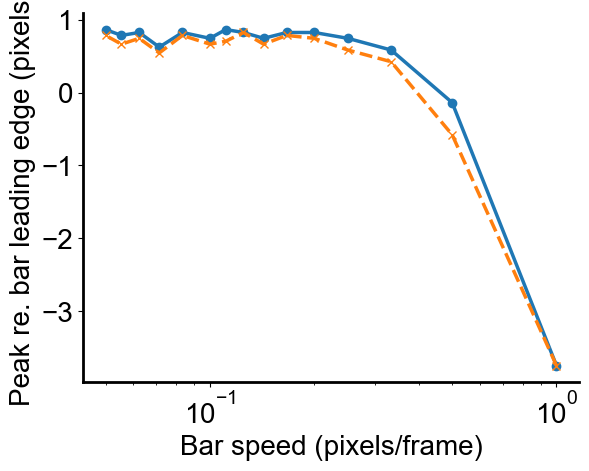

In [19]:
plt.figure()
bar_speedsa = 1/bar_speeds.astype(float)
rel_max_positionsa = np.array(rel_max_positions)
rel_max_positionsa_ablate = np.array(rel_max_positions_ablate)
ax = plt.plot(bar_speedsa,rel_max_positionsa, marker='o')
ax = plt.plot(bar_speedsa,rel_max_positionsa_ablate, marker='x', linestyle='--')
plt.tick_params(axis='both', labelsize=fontsize) 
plt.xscale('log')
plt.xlabel('Bar speed (pixels/frame)',fontsize=fontsize)
plt.ylabel('Peak re. bar leading edge (pixels)',fontsize=fontsize)
plt.grid(False)  # Remove grid
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)